# NLP Tutor — Assistant pédagogique francophone en NLP

## Objectif

Construire, comprendre, adapter et évaluer un assistant pédagogique spécialisé dans les notions fondamentales du NLP et des Transformers.

Deux configurations sont comparées :

1. **Baseline** : `Qwen/Qwen2.5-1.5B-Instruct` utilisé avec prompting ;
2. **QLoRA** : le même modèle, quantifié en 4 bits, avec des adaptateurs LoRA entraînés sur un petit dataset pédagogique.



## 0. Préparation du projet



In [3]:
# ============================================================
# 0. PRÉPARATION DU PROJET
# ============================================================

from pathlib import Path
import sys
import os
import importlib

PROJECT_ROOT = Path("/content/nlp_tutor").resolve()
SRC_DIR = PROJECT_ROOT / "src"
PACKAGE_DIR = SRC_DIR / "nlp_tutor"

# ------------------------------------------------------------
# Vérification du projet
# ------------------------------------------------------------

required_files = [
    PROJECT_ROOT / "pyproject.toml",
    PACKAGE_DIR / "__init__.py",
    PACKAGE_DIR / "config.py",
    PACKAGE_DIR / "model.py",
    PACKAGE_DIR / "generation.py",
    PACKAGE_DIR / "dataset.py",
    PACKAGE_DIR / "evaluation.py",
    PACKAGE_DIR / "training.py",
]

missing = [p for p in required_files if not p.exists()]

if missing:
    print("❌ Fichiers manquants :")
    for p in missing:
        print(" -", p)

    raise RuntimeError(
        "Le projet /content/nlp_tutor est incomplet."
    )

print(" Tous les fichiers du projet sont présents.")

# ------------------------------------------------------------
# IMPORTANT : utiliser directement src/
# ------------------------------------------------------------

# Supprimer les anciens chemins éventuels
src_str = str(SRC_DIR)

sys.path = [
    p for p in sys.path
    if p != src_str
]

# Mettre notre src en priorité ABSOLUE
sys.path.insert(0, src_str)

# Supprimer un éventuel mauvais nlp_tutor déjà chargé
for module_name in list(sys.modules):
    if (
        module_name == "nlp_tutor"
        or module_name.startswith("nlp_tutor.")
    ):
        del sys.modules[module_name]

importlib.invalidate_caches()

# ------------------------------------------------------------
# Test réel
# ------------------------------------------------------------

import nlp_tutor

print("\nPackage chargé depuis :")
print(nlp_tutor.__file__)

from nlp_tutor.config import MODEL_ID, SEED, SYSTEM_PROMPT

print("\n✅ nlp_tutor.config fonctionne")
print("MODEL_ID :", MODEL_ID)
print("SEED :", SEED)

# On revient à la racine du projet pour le reste du notebook
os.chdir(PROJECT_ROOT)

print("\nPROJECT_ROOT :", PROJECT_ROOT)
print("SRC_DIR :", SRC_DIR)
print("Dossier courant :", Path.cwd())

print("\n PRÉPARATION TERMINÉE")

 Tous les fichiers du projet sont présents.

Package chargé depuis :
/content/nlp_tutor/src/nlp_tutor/__init__.py

✅ nlp_tutor.config fonctionne
MODEL_ID : Qwen/Qwen2.5-1.5B-Instruct
SEED : 42

PROJECT_ROOT : /content/nlp_tutor
SRC_DIR : /content/nlp_tutor/src
Dossier courant : /content/nlp_tutor

 PRÉPARATION TERMINÉE


## 1. Vérification de l'environnement

In [4]:
import gc
import math
import random
import sys

import numpy as np
import pandas as pd
import torch

print("Python :", sys.version.split()[0])
print("PyTorch :", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

    total_vram = (
        torch.cuda.get_device_properties(0).total_memory
        / 1024**3
    )

    print(f"VRAM totale : {total_vram:.1f} Gio")

Python : 3.13.15
PyTorch : 2.11.0+cu128
CUDA disponible : True
GPU : Tesla T4
VRAM totale : 14.6 Gio


In [5]:
%pip install -q trl

print(" TRL installé")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 24.6 MB/s eta 0:00:0000:01
 TRL installé


In [7]:
%pip install -q rouge-score

print("✅ rouge-score installé")

  Preparing metadata (setup.py) ... done
✅ rouge-score installé


## 2. Imports du projet

In [8]:
from nlp_tutor.config import (
    MODEL_ID,
    SEED,
    SYSTEM_PROMPT,
)

from nlp_tutor.model import (
    load_tokenizer,
    load_base_model,
    load_qlora_base_model,
    load_finetuned_model,
)

from nlp_tutor.generation import (
    generate_tutor,
    generate_with_strategy,
)

from nlp_tutor.dataset import build_dataset

from nlp_tutor.evaluation import (
    normalize_text,
    keyword_coverage,
    compute_rouge_l,
    evaluate_dataset,
    summarize_results,
    save_results,
)

from nlp_tutor.training import (
    build_lora_config,
    build_training_args,
    build_trainer,
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Imports NLP Tutor : OK")
print("Modèle :", MODEL_ID)
print("Seed :", SEED)

Imports NLP Tutor : OK
Modèle : Qwen/Qwen2.5-1.5B-Instruct
Seed : 42


## 3. Tokenisation

Un modèle de langage ne manipule pas directement des « mots » : il manipule des **tokens** représentés par des identifiants numériques.

In [9]:
tokenizer = load_tokenizer()

texte = "Un modèle de langage prédit le prochain token."

encodage = tokenizer(
    texte,
    add_special_tokens=False,
)

token_ids = encodage["input_ids"]

df_tokens = pd.DataFrame({
    "position": range(len(token_ids)),
    "token_id": token_ids,
    "token_interne": tokenizer.convert_ids_to_tokens(token_ids),
    "morceau_decode": [tokenizer.decode([i]) for i in token_ids],
})

print("Texte original :", texte)
print("Nombre de mots séparés par des espaces :", len(texte.split()))
print("Nombre de tokens :", len(token_ids))
display(df_tokens)

texte_reconstruit = tokenizer.decode(
    token_ids,
    clean_up_tokenization_spaces=False,
)

print("\nTexte reconstruit :", texte_reconstruit)
print("Reconstruction identique :", texte_reconstruit == texte)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Texte original : Un modèle de langage prédit le prochain token.
Nombre de mots séparés par des espaces : 8
Nombre de tokens : 13


,position,token_id,token_interne,morceau_decode
0,0,1806,Un,Un
1,1,82497,ĠmodÃ¨le,modèle
2,2,409,Ġde,de
3,3,8688,Ġlang,lang
4,4,424,age,age
5,5,548,Ġpr,pr
6,6,15083,Ã©d,éd
7,7,275,it,it
8,8,512,Ġle,le
9,9,462,Ġpro,pro



Texte reconstruit : Un modèle de langage prédit le prochain token.
Reconstruction identique : True


**Interprétation.** Un mot peut correspondre à un ou plusieurs tokens. Les identifiants numériques sont les entrées discrètes qui seront ensuite transformées en représentations vectorielles.

## 4. Logits, softmax et argmax

In [10]:
logits_demo = torch.tensor([2.0, 1.0, 0.0])
tokens_demo = ["chat", "chien", "table"]

probas_demo = torch.softmax(logits_demo, dim=-1)
indice_argmax = torch.argmax(probas_demo).item()

display(pd.DataFrame({
    "token": tokens_demo,
    "logit": logits_demo.tolist(),
    "probabilite": probas_demo.tolist(),
}))

print("Somme des probabilités :", probas_demo.sum().item())
print("Argmax :", tokens_demo[indice_argmax])

,token,logit,probabilite
0,chat,2.0,0.665241
1,chien,1.0,0.244728
2,table,0.0,0.090031


Somme des probabilités : 1.0
Argmax : chat


**Important :** les logits sont des scores bruts. La softmax les transforme en distribution de probabilités. L'argmax sélectionne l'indice du score maximal.

## 5. Effet de la température sur une distribution simple

In [11]:
rows = []

for T in [0.5, 1.0, 1.5, 2.0]:
    probs = torch.softmax(logits_demo / T, dim=-1)

    for token, p in zip(tokens_demo, probs.tolist()):
        rows.append({
            "temperature": T,
            "token": token,
            "probabilite": p,
        })

df_temp = pd.DataFrame(rows)

display(
    df_temp.pivot(
        index="token",
        columns="temperature",
        values="probabilite",
    ).round(4)
)

temperature,0.5,1.0,1.5,2.0
token,,,,
chat,0.8668,0.6652,0.5627,0.5065
chien,0.1173,0.2447,0.2889,0.3072
table,0.0159,0.0900,0.1483,0.1863


**Interprétation.** Une température basse concentre davantage la distribution ; une température élevée l'aplatit et rend l'échantillonnage potentiellement plus divers.

## 6. Chargement du modèle de base

In [12]:
if not torch.cuda.is_available():
    raise RuntimeError(
        "La suite du notebook nécessite un GPU CUDA. "
        "Connecte le notebook à un runtime Colab GPU."
    )

base_model = load_base_model()

print("Modèle de base chargé.")
print("Device :", next(base_model.parameters()).device)

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modèle de base chargé.
Device : cuda:0


## 7. Observer les vrais logits du modèle

In [13]:
prompt_logits = "Un modèle de langage prédit"

inputs_logits = tokenizer(
    prompt_logits,
    return_tensors="pt",
    add_special_tokens=False,
).to(next(base_model.parameters()).device)

with torch.inference_mode():
    outputs_logits = base_model(**inputs_logits)

next_logits = outputs_logits.logits[0, -1]
next_probs = torch.softmax(next_logits, dim=-1)

top_probs, top_ids = torch.topk(next_probs, k=10)

df_top = pd.DataFrame({
    "token_id": top_ids.cpu().tolist(),
    "token_decode": [
        repr(tokenizer.decode([i]))
        for i in top_ids.cpu().tolist()
    ],
    "probabilite": top_probs.float().cpu().tolist(),
})

display(df_top)

argmax_id = torch.argmax(next_probs).item()
print("Argmax :", repr(tokenizer.decode([argmax_id])))

,token_id,token_decode,probabilite
0,512,' le',0.160278
1,3541,' les',0.092773
2,1187,' la',0.076904
3,1709,' que',0.057159
4,326,' l',0.053680
5,1346,' par',0.050446
6,650,' un',0.038086
7,939,' des',0.033600
8,333,'if',0.025757
9,6185,' une',0.023453


Argmax : ' le'


## 8. Température appliquée aux vrais logits

In [14]:
rows = []

for T in [0.5, 1.0, 1.5]:
    probs = torch.softmax(next_logits / T, dim=-1)
    top_probs, top_ids = torch.topk(probs, k=5)

    for rank, (token_id, p) in enumerate(
        zip(top_ids.tolist(), top_probs.tolist()),
        start=1,
    ):
        rows.append({
            "temperature": T,
            "rang": rank,
            "token": repr(tokenizer.decode([token_id])),
            "probabilite": float(p),
        })

display(pd.DataFrame(rows))

,temperature,rang,token,probabilite
0,0.5,1,' le',0.475342
1,0.5,2,' les',0.159180
2,0.5,3,' la',0.109436
3,0.5,4,' que',0.060425
4,0.5,5,' l',0.053345
5,1.0,1,' le',0.160278
6,1.0,2,' les',0.092773
7,1.0,3,' la',0.076904
8,1.0,4,' que',0.057159
9,1.0,5,' l',0.053680


## 9. Greedy, température, top-k et top-p

In [15]:
question_decodage = "Explique simplement ce qu'est un token en NLP."

strategies = [
    ("greedy", dict(do_sample=False)),
    ("temperature_0.7", dict(do_sample=True, temperature=0.7)),
    ("top_k_20", dict(do_sample=True, temperature=0.8, top_k=20)),
    ("top_p_0.9", dict(do_sample=True, temperature=0.8, top_p=0.9)),
]

results_decoding = []

for name, params in strategies:
    response = generate_with_strategy(
        question_decodage,
        base_model,
        tokenizer,
        **params,
    )
    results_decoding.append({
        "strategie": name,
        "reponse": response,
    })

display(pd.DataFrame(results_decoding))

,strategie,reponse
0,greedy,"Un ""token"" dans le domaine de l'NLP (Natural L..."
1,temperature_0.7,Un token en NLP (Nouvelles Linguistiques du Pa...
2,top_k_20,"En NLP (Nécessairement Langage Naturel), un ""t..."
3,top_p_0.9,"Un ""token"" en NLP (Niveau de Compréhension et ..."


## 10. Baseline par prompting

La baseline utilise le modèle de base sans adaptation des poids. Le comportement pédagogique est uniquement défini par le prompt système.

In [16]:
baseline_questions = [
    "Qu'est-ce qu'un token en NLP ?",
    "À quoi sert l'attention dans un Transformer ?",
    "Quelle est la différence entre fine-tuning et prompting ?",
]

for question in baseline_questions:
    print("=" * 100)
    print("QUESTION :", question)
    print(
        generate_tutor(
            question,
            base_model,
            tokenizer,
            do_sample=False,
        )
    )
    print()

QUESTION : Qu'est-ce qu'un token en NLP ?
Un token en NLP (Nécessaire Langue Présente) est un élément de texte qui peut être traité comme un point d'entrée pour le traitement automatique du langage naturel (TALN). C'est un terme générique qui désigne généralement un caractère ou un groupe de caractères dans un texte.

Par exemple, dans un texte "Bonjour, comment vas-tu ?", les tokens seraient :

- "Bonjour"
- " "
- "comment"
- " "
- "vas"
- " "
- "tu"
- "?"

Chaque token est ensuite analysé et traité séparément par des algorithmes de NLP pour comprendre le sens du texte.

QUESTION : À quoi sert l'attention dans un Transformer ?
L'attention dans un Transformer est comme un guide pour le modèle. Elle aide le modèle à se concentrer sur les informations importantes dans la chaîne de caractères qu'il lit. Imagine que tu lis un livre. L'attention serait comme un oeil qui suit les personnages ou les événements importants. Cela permet au modèle de comprendre ce qui est crucial pour résoudre un

## 11. Construction du dataset pédagogique

In [17]:
dataset = build_dataset()

print(dataset)
print()
print("Train      :", len(dataset["train"]))
print("Validation :", len(dataset["validation"]))
print("Test       :", len(dataset["test"]))

display(
    pd.DataFrame(dataset["train"].select(range(3)))[
        ["concept", "question", "reference"]
    ]
)

DatasetDict({
    train: Dataset({
        features: ['concept', 'question', 'reference', 'keywords', 'prompt', 'completion'],
        num_rows: 350
    })
    validation: Dataset({
        features: ['concept', 'question', 'reference', 'keywords', 'prompt', 'completion'],
        num_rows: 75
    })
    test: Dataset({
        features: ['concept', 'question', 'reference', 'keywords', 'prompt', 'completion'],
        num_rows: 75
    })
})

Train      : 350
Validation : 75
Test       : 75


,concept,question,reference
0,token,Donne-moi une fiche de révision rapide sur token.,Un token est une unité de texte manipulée par ...
1,token,Donne-moi une explication pédagogique de token.,Un token est une unité de texte manipulée par ...
2,token,Comment fonctionne token globalement ?,Un token est une unité de texte manipulée par ...


Le protocole utilise **350 exemples d'entraînement, 75 de validation et 75 de test**. Les splits portent sur des formulations différentes des mêmes concepts ; il faut donc compléter cette évaluation par des questions réellement inédites.

## 12. Sélection reproductible de 20 requêtes de test

In [18]:
eval20 = dataset["test"].shuffle(seed=123).select(range(20))

display(pd.DataFrame({
    "concept": eval20["concept"],
    "question": eval20["question"],
}))

,concept,question
0,masque causal,C'est quoi masque causal en NLP ?
1,tokenizer,Comment expliquer tokenizer à un débutant ?
2,température,Donne une définition courte puis une explicati...
3,token,Explique-moi simplement token.
4,LoRA,Donne-moi une explication pédagogique de LoRA.
5,fenêtre de contexte,Explique le rôle de fenêtre de contexte.
6,embedding,Donne une définition courte puis une explicati...
7,train validation test,Peux-tu définir train validation test ?
8,train validation test,Donne une définition courte puis une explicati...
9,attention,Fais un résumé clair de attention.


## 13. Évaluation automatique de la baseline

In [19]:
baseline_results = evaluate_dataset(
    model=base_model,
    tokenizer=tokenizer,
    eval_dataset=eval20,
    model_name="Qwen2.5-1.5B + prompting",
)

display(
    baseline_results[
        ["id", "concept", "question", "rougeL_f1", "keyword_coverage"]
    ]
)

baseline_summary = summarize_results(baseline_results)
print(baseline_summary)

save_results(
    baseline_results,
    PROJECT_ROOT / "results" / "baseline_results.csv",
)

,id,concept,question,rougeL_f1,keyword_coverage
0,1,masque causal,C'est quoi masque causal en NLP ?,0.098522,0.00
1,2,tokenizer,Comment expliquer tokenizer à un débutant ?,0.130719,0.00
2,3,température,Donne une définition courte puis une explicati...,0.157895,0.00
3,4,token,Explique-moi simplement token.,0.225806,0.75
4,5,LoRA,Donne-moi une explication pédagogique de LoRA.,0.106383,0.00
5,6,fenêtre de contexte,Explique le rôle de fenêtre de contexte.,0.167488,0.25
6,7,embedding,Donne une définition courte puis une explicati...,0.116402,0.50
7,8,train validation test,Peux-tu définir train validation test ?,0.086124,0.50
8,9,train validation test,Donne une définition courte puis une explicati...,0.103448,0.50
9,10,attention,Fais un résumé clair de attention.,0.068966,0.00


{'nombre_questions': 20, 'rougeL_moyen': np.float64(0.13312116036651164), 'keyword_coverage_moyenne': np.float64(0.25)}
Résultats sauvegardés : /content/nlp_tutor/results/baseline_results.csv


### Limite méthodologique

ROUGE-L mesure un recouvrement de séquences et la couverture de mots-clés mesure la présence de termes attendus. Ces métriques ne suffisent pas à juger toute la qualité pédagogique. Elles seront complétées par un test de généralisation et une analyse qualitative.

## 14. Questions de généralisation réellement nouvelles

In [20]:
CHALLENGE_QUESTIONS = [
    "Pourquoi un même mot peut-il être découpé différemment selon le tokenizer ?",
    "Quelle différence y a-t-il entre les logits et les probabilités finales ?",
    "Pourquoi une température très élevée peut-elle dégrader une réponse ?",
    "Dans quel cas top-p est-il préférable à top-k ?",
    "Pourquoi un Transformer a-t-il besoin d'informations de position ?",
    "Que se passerait-il sans masque causal pendant l'entraînement d'un modèle autoregressif ?",
    "Pourquoi Q, K et V ont-ils des rôles différents dans l'attention ?",
    "Quelle différence fais-tu entre self-attention et attention en général ?",
    "Pourquoi QLoRA consomme-t-il moins de mémoire qu'un fine-tuning complet ?",
    "Quelle est la différence entre quantifier un modèle et le fine-tuner ?",
    "Pourquoi un faible training loss ne garantit-il pas une bonne généralisation ?",
    "Comment détecter un surapprentissage avec train et validation ?",
    "Pourquoi faut-il garder le jeu de test indépendant ?",
    "Quelle différence existe-t-il entre pré-entraînement et instruction tuning ?",
    "Que représente concrètement un embedding ?",
    "Pourquoi une grande fenêtre de contexte coûte-t-elle plus cher en calcul ?",
    "Comment un modèle choisit-il le prochain token quand do_sample=False ?",
    "Pourquoi peut-on obtenir des réponses différentes avec la même question quand do_sample=True ?",
    "Quelle est la principale limitation de LoRA par rapport à un fine-tuning complet ?",
    "Explique le chemin complet allant d'une phrase entrée par l'utilisateur jusqu'au prochain token généré.",
]

assert len(CHALLENGE_QUESTIONS) == 20

display(pd.DataFrame({
    "id": range(1, 21),
    "question": CHALLENGE_QUESTIONS,
}))

,id,question
0,1,Pourquoi un même mot peut-il être découpé diff...
1,2,Quelle différence y a-t-il entre les logits et...
2,3,Pourquoi une température très élevée peut-elle...
3,4,Dans quel cas top-p est-il préférable à top-k ?
4,5,Pourquoi un Transformer a-t-il besoin d'inform...
5,6,Que se passerait-il sans masque causal pendant...
6,7,"Pourquoi Q, K et V ont-ils des rôles différent..."
7,8,Quelle différence fais-tu entre self-attention...
8,9,Pourquoi QLoRA consomme-t-il moins de mémoire ...
9,10,Quelle est la différence entre quantifier un m...


### Baseline sur le challenge

On calcule ces réponses avant de libérer le modèle de base, afin d'éviter de devoir le recharger plus tard.

In [21]:
baseline_challenge = []

for i, question in enumerate(CHALLENGE_QUESTIONS, start=1):
    response = generate_tutor(
        question,
        base_model,
        tokenizer,
        do_sample=False,
        max_new_tokens=220,
    )

    baseline_challenge.append({
        "id": i,
        "question": question,
        "baseline": response,
    })

baseline_challenge = pd.DataFrame(baseline_challenge)
display(baseline_challenge)

,id,question,baseline
0,1,Pourquoi un même mot peut-il être découpé diff...,Un même mot peut être découpé différemment sel...
1,2,Quelle différence y a-t-il entre les logits et...,Les logits et les probabilités finales sont de...
2,3,Pourquoi une température très élevée peut-elle...,Une température très élevée peut dégrader une ...
3,4,Dans quel cas top-p est-il préférable à top-k ?,Top-p (ou top-k) sont deux méthodes pour filtr...
4,5,Pourquoi un Transformer a-t-il besoin d'inform...,Un Transformer a besoin d'informations de posi...
5,6,Que se passerait-il sans masque causal pendant...,Sans masque causal pendant l'entraînement d'un...
6,7,"Pourquoi Q, K et V ont-ils des rôles différent...","Les Q, K et V sont des matrices d'attention ut..."
7,8,Quelle différence fais-tu entre self-attention...,La différence entre la self-attention et l'att...
8,9,Pourquoi QLoRA consomme-t-il moins de mémoire ...,QLoRA (Quantized LoRA) consomme moins de mémoi...
9,10,Quelle est la différence entre quantifier un m...,La quantification d'un modèle et le fine-tunin...


## 15. Libération du modèle de base

In [22]:
del base_model
gc.collect()
torch.cuda.empty_cache()

print("Modèle de base libéré et cache CUDA nettoyé.")

Modèle de base libéré et cache CUDA nettoyé.


In [23]:
# ============================================================
# Installation de bitsandbytes pour la quantification 4 bits
# ============================================================
#
# bitsandbytes est utilisé par Transformers pour charger
# le modèle Qwen en 4 bits dans notre pipeline QLoRA.
# ============================================================

%pip install -q -U bitsandbytes

print(" bitsandbytes installé")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 19.1 MB/s eta 0:00:00:00:0100:01
 bitsandbytes installé


In [ ]:
# ============================================================
# Vérification de bitsandbytes
# ============================================================

import bitsandbytes as bnb
import torch

print("bitsandbytes :", bnb.__version__)
print("PyTorch      :", torch.__version__)
print("CUDA         :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))

print("\n Environnement QLoRA prêt")

bitsandbytes : 0.50.2
PyTorch      : 2.11.0+cu128
CUDA         : True
GPU          : Tesla T4

 Environnement QLoRA prêt


In [24]:
# ============================================================
#
# QLoRA repose ici sur une quantification 4 bits.
# Transformers utilise bitsandbytes pour charger le modèle
# quantifié et accelerate pour la gestion du chargement/device.
# ============================================================

import torch
import transformers
import accelerate
import bitsandbytes as bnb

print("PyTorch       :", torch.__version__)
print("Transformers  :", transformers.__version__)
print("Accelerate    :", accelerate.__version__)
print("BitsAndBytes  :", bnb.__version__)

print()
print("CUDA disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

print("\n Dépendances QLoRA accessibles")

PyTorch       : 2.11.0+cu128
Transformers  : 5.16.1
Accelerate    : 1.14.0
BitsAndBytes  : 0.50.2

CUDA disponible : True
GPU : Tesla T4

 Dépendances QLoRA accessibles


## 16. Préparation de QLoRA

Le même modèle de base est rechargé en 4 bits. Les poids principaux restent gelés et des adaptateurs LoRA entraînables sont ajoutés par le trainer.

In [25]:
qlora_model = load_qlora_base_model()

lora_config = build_lora_config()

print(lora_config)
print("Modèle 4 bits prêt pour QLoRA.")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.20.0', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'v_proj', 'up_proj', 'o_proj', 'k_proj', 'down_proj', 'gate_proj', 'q_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)
Modèle 

## 17. Construction du trainer

In [26]:
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "checkpoints"

trainer = build_trainer(
    model=qlora_model,
    tokenizer=tokenizer,
    dataset=dataset,
    output_dir=str(OUTPUT_DIR),
)

trainer.model.print_trainable_parameters()

Tokenizing train dataset:   0%|          | 0/350 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/350 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/350 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/350 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/75 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/75 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/75 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/75 [00:00<?, ? examples/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


**Interprétation.** Le nombre de paramètres entraînables doit être très inférieur au nombre total de paramètres. Avec `batch_size=2` et `gradient_accumulation_steps=8`, le batch effectif vaut 16 exemples.

## 18. Entraînement

In [27]:
train_result = trainer.train()
train_result

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.972913,0.320549,0.535288,64037.000000,0.917488
2,0.033338,0.013707,0.068146,128074.000000,0.998784


TrainOutput(global_step=44, training_loss=0.7145652567798441, metrics={'train_runtime': 335.0575, 'train_samples_per_second': 2.089, 'train_steps_per_second': 0.131, 'total_flos': 1048650680967168.0, 'train_loss': 0.7145652567798441, 'epoch': 2.0})

## 19. Validation et sauvegarde de l'adaptateur

In [28]:
eval_metrics = trainer.evaluate()
print(eval_metrics)

if "eval_loss" in eval_metrics:
    eval_loss = eval_metrics["eval_loss"]
    perplexity = math.exp(eval_loss) if eval_loss < 20 else float("inf")
    print("Perplexité validation :", perplexity)

ADAPTER_DIR = PROJECT_ROOT / "artifacts" / "lora_adapter"
ADAPTER_DIR.mkdir(parents=True, exist_ok=True)

trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print("Adaptateur sauvegardé dans :", ADAPTER_DIR)

Training Loss,Validation Loss,Epoch,Entropy,Num Tokens,Mean Token Accuracy
0.033338,0.013707,2,0.068146,128074.000000,0.998784


{'eval_loss': 0.013707442209124565, 'eval_entropy': 0.06814562176403247, 'eval_num_tokens': 128074.0, 'eval_mean_token_accuracy': 0.9987838205538297}
Perplexité validation : 1.0138018199277576
Adaptateur sauvegardé dans : /content/nlp_tutor/artifacts/lora_adapter


## 20. Évaluation après QLoRA

In [29]:
finetuned_model = trainer.model
finetuned_model.config.use_cache = True
finetuned_model.eval()

finetuned_results = evaluate_dataset(
    model=finetuned_model,
    tokenizer=tokenizer,
    eval_dataset=eval20,
    model_name="Qwen2.5-1.5B + QLoRA",
)

display(
    finetuned_results[
        ["id", "concept", "question", "rougeL_f1", "keyword_coverage"]
    ]
)

finetuned_summary = summarize_results(finetuned_results)
print(finetuned_summary)

save_results(
    finetuned_results,
    PROJECT_ROOT / "results" / "qlora_results.csv",
)

,id,concept,question,rougeL_f1,keyword_coverage
0,1,masque causal,C'est quoi masque causal en NLP ?,1.0,0.75
1,2,tokenizer,Comment expliquer tokenizer à un débutant ?,1.0,1.00
2,3,température,Donne une définition courte puis une explicati...,1.0,0.75
3,4,token,Explique-moi simplement token.,1.0,1.00
4,5,LoRA,Donne-moi une explication pédagogique de LoRA.,1.0,0.75
5,6,fenêtre de contexte,Explique le rôle de fenêtre de contexte.,1.0,0.75
6,7,embedding,Donne une définition courte puis une explicati...,1.0,1.00
7,8,train validation test,Peux-tu définir train validation test ?,1.0,0.75
8,9,train validation test,Donne une définition courte puis une explicati...,1.0,0.75
9,10,attention,Fais un résumé clair de attention.,1.0,1.00


{'nombre_questions': 20, 'rougeL_moyen': np.float64(1.0), 'keyword_coverage_moyenne': np.float64(0.8375)}
Résultats sauvegardés : /content/nlp_tutor/results/qlora_results.csv


## 21. Comparaison baseline / QLoRA

In [30]:
summary = pd.DataFrame({
    "configuration": [
        "Baseline : modèle + prompting",
        "Après QLoRA",
    ],
    "ROUGE-L moyen": [
        baseline_results["rougeL_f1"].mean(),
        finetuned_results["rougeL_f1"].mean(),
    ],
    "Couverture mots-clés moyenne": [
        baseline_results["keyword_coverage"].mean(),
        finetuned_results["keyword_coverage"].mean(),
    ],
})

display(summary.round(4))

print(
    "Δ ROUGE-L :",
    round(
        finetuned_results["rougeL_f1"].mean()
        - baseline_results["rougeL_f1"].mean(),
        4,
    ),
)

print(
    "Δ couverture :",
    round(
        finetuned_results["keyword_coverage"].mean()
        - baseline_results["keyword_coverage"].mean(),
        4,
    ),
)

,configuration,ROUGE-L moyen,Couverture mots-clés moyenne
0,Baseline : modèle + prompting,0.1331,0.2500
1,Après QLoRA,1.0000,0.8375


Δ ROUGE-L : 0.8669
Δ couverture : 0.5875


In [31]:
comparison = baseline_results[
    ["id", "concept", "question", "reference", "prediction"]
].rename(columns={"prediction": "baseline"})

comparison["qlora"] = finetuned_results["prediction"]

display(comparison)

comparison.to_csv(
    PROJECT_ROOT / "results" / "baseline_vs_qlora.csv",
    index=False,
)

,id,concept,question,reference,baseline,qlora
0,1,masque causal,C'est quoi masque causal en NLP ?,Un masque causal empêche une position de consu...,Le masque causal est un concept important dans...,Un masque causal empêche une position de consu...
1,2,tokenizer,Comment expliquer tokenizer à un débutant ?,Un tokenizer transforme un texte en tokens pui...,Un tokenizer est comme un petit robot qui divi...,Un tokenizer transforme un texte en tokens pui...
2,3,température,Donne une définition courte puis une explicati...,La température modifie la distribution utilisé...,La température est un concept scientifique qui...,La température modifie la distribution utilisé...
3,4,token,Explique-moi simplement token.,Un token est une unité de texte manipulée par ...,"Un token, aussi appelé ""tokeniser"", est un élé...",Un token est une unité de texte manipulée par ...
4,5,LoRA,Donne-moi une explication pédagogique de LoRA.,LoRA gèle les principaux poids du modèle et aj...,"LoRA, ou Low-Rank Adaptation, est un concept i...",LoRA gèle les principaux poids du modèle et aj...
5,6,fenêtre de contexte,Explique le rôle de fenêtre de contexte.,La fenêtre de contexte est la quantité maximal...,Le rôle de la fenêtre de contexte dans les mod...,La fenêtre de contexte est la quantité maximal...
6,7,embedding,Donne une définition courte puis une explicati...,Un embedding est un vecteur numérique représen...,**Définition :** L'embedding est un concept ce...,Un embedding est un vecteur numérique représen...
7,8,train validation test,Peux-tu définir train validation test ?,"Le train sert à ajuster les paramètres, la val...",Bien sûr ! La division en train-validation-tes...,"Le train sert à ajuster les paramètres, la val..."
8,9,train validation test,Donne une définition courte puis une explicati...,"Le train sert à ajuster les paramètres, la val...",La **validation** est une étape importante dan...,"Le train sert à ajuster les paramètres, la val..."
9,10,attention,Fais un résumé clair de attention.,L'attention permet de pondérer l'importance de...,Attention est un concept fondamental dans le d...,L'attention permet de pondérer l'importance de...


## 22. Généralisation : baseline vs QLoRA sur 20 questions inédites

Ces questions ne sont pas des reformulations directes générées par les templates du dataset. Elles servent à vérifier si l'adaptation améliore réellement le comportement au-delà de la mémorisation des réponses de référence.

In [32]:
qlora_challenge = []

for i, question in enumerate(CHALLENGE_QUESTIONS, start=1):
    response = generate_tutor(
        question,
        finetuned_model,
        tokenizer,
        do_sample=False,
        max_new_tokens=220,
    )

    qlora_challenge.append({
        "id": i,
        "qlora": response,
    })

qlora_challenge = pd.DataFrame(qlora_challenge)

challenge_comparison = baseline_challenge.merge(
    qlora_challenge,
    on="id",
    how="inner",
)

display(challenge_comparison)

challenge_comparison.to_csv(
    PROJECT_ROOT / "results" / "challenge_comparison.csv",
    index=False,
)

,id,question,baseline,qlora
0,1,Pourquoi un même mot peut-il être découpé diff...,Un même mot peut être découpé différemment sel...,Un tokenizer transforme un texte en tokens pui...
1,2,Quelle différence y a-t-il entre les logits et...,Les logits et les probabilités finales sont de...,Les logits sont les scores bruts produits par ...
2,3,Pourquoi une température très élevée peut-elle...,Une température très élevée peut dégrader une ...,La température modifie la distribution utilisé...
3,4,Dans quel cas top-p est-il préférable à top-k ?,Top-p (ou top-k) sont deux méthodes pour filtr...,Le top-p conserve le plus petit ensemble de to...
4,5,Pourquoi un Transformer a-t-il besoin d'inform...,Un Transformer a besoin d'informations de posi...,Un Transformer utilise un encoder autoreductif...
5,6,Que se passerait-il sans masque causal pendant...,Sans masque causal pendant l'entraînement d'un...,Un masque causal empêche le modèle de prédire ...
6,7,"Pourquoi Q, K et V ont-ils des rôles différent...","Les Q, K et V sont des matrices d'attention ut...","La quantité Q est le poids de la position, K e..."
7,8,Quelle différence fais-tu entre self-attention...,La différence entre la self-attention et l'att...,La self-attention applique l'attention entre l...
8,9,Pourquoi QLoRA consomme-t-il moins de mémoire ...,QLoRA (Quantized LoRA) consomme moins de mémoi...,"QLoRA combine un modèle de base quantifié, sou..."
9,10,Quelle est la différence entre quantifier un m...,La quantification d'un modèle et le fine-tunin...,Un fine-tuner apprend des régularités dans un ...


In [33]:
# ============================================================
# DIAGNOSTIC ET RESTAURATION DU CHALLENGE
# ============================================================
#
# Cette cellule sert à retrouver les résultats déjà calculés.
#
# Pourquoi ?
# Lorsque le runtime Colab redémarre :
# - le code du notebook reste présent ;
# - les anciennes sorties restent visibles ;
# - MAIS les variables Python en mémoire disparaissent.
#
# Nous allons donc vérifier si les résultats ont été sauvegardés
# dans le dossier results/ et les recharger automatiquement.
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# 1. Retrouver la racine du projet
# ------------------------------------------------------------

# Dans notre cas, le projet est normalement ici sur Colab.
PROJECT_ROOT = Path("/content/nlp_tutor")

print("=== 1. PROJET ===")
print("Chemin du projet :", PROJECT_ROOT)
print("Projet trouvé     :", PROJECT_ROOT.exists())


# ------------------------------------------------------------
# 2. Vérifier le dossier results
# ------------------------------------------------------------

RESULTS_DIR = PROJECT_ROOT / "results"

print("\n=== 2. DOSSIER RESULTS ===")
print("Chemin :", RESULTS_DIR)
print("Existe :", RESULTS_DIR.exists())


# ------------------------------------------------------------
# 3. Afficher les fichiers disponibles
# ------------------------------------------------------------

if RESULTS_DIR.exists():

    fichiers = sorted(RESULTS_DIR.glob("*"))

    print("\nFichiers trouvés :")

    if len(fichiers) == 0:
        print("Aucun fichier dans results/")
    else:
        for fichier in fichiers:
            print(" -", fichier.name)

else:
    print("\nLe dossier results/ n'existe pas.")


# ------------------------------------------------------------
# 4. Chercher challenge_comparison.csv
# ------------------------------------------------------------

challenge_file = (
    RESULTS_DIR
    / "challenge_comparison.csv"
)

print("\n=== 3. CHALLENGE ===")
print("Fichier recherché :", challenge_file)
print("Existe            :", challenge_file.exists())


# ------------------------------------------------------------
# 5. Si le fichier existe, on le recharge
# ------------------------------------------------------------

if challenge_file.exists():

    challenge_comparison = pd.read_csv(
        challenge_file
    )

    print("\n challenge_comparison restauré !")

    print(
        "Nombre de questions :",
        len(challenge_comparison)
    )

    print(
        "Colonnes :",
        list(challenge_comparison.columns)
    )

    # Affiche seulement les premières lignes
    # pour vérifier que tout est correct.
    display(
        challenge_comparison.head()
    )

else:

    print(
        "\n challenge_comparison.csv "
        "n'a pas été trouvé."
    )

    print(
        "Ce n'est pas grave : "
        "nous le reconstruirons à partir "
        "des étapes précédentes du notebook."
    )

=== 1. PROJET ===
Chemin du projet : /content/nlp_tutor
Projet trouvé     : True

=== 2. DOSSIER RESULTS ===
Chemin : /content/nlp_tutor/results
Existe : True

Fichiers trouvés :
 - baseline_results.csv
 - baseline_vs_qlora.csv
 - challenge_comparison.csv
 - qlora_results.csv

=== 3. CHALLENGE ===
Fichier recherché : /content/nlp_tutor/results/challenge_comparison.csv
Existe            : True

 challenge_comparison restauré !
Nombre de questions : 20
Colonnes : ['id', 'question', 'baseline', 'qlora']


,id,question,baseline,qlora
0,1,Pourquoi un même mot peut-il être découpé diff...,Un même mot peut être découpé différemment sel...,Un tokenizer transforme un texte en tokens pui...
1,2,Quelle différence y a-t-il entre les logits et...,Les logits et les probabilités finales sont de...,Les logits sont les scores bruts produits par ...
2,3,Pourquoi une température très élevée peut-elle...,Une température très élevée peut dégrader une ...,La température modifie la distribution utilisé...
3,4,Dans quel cas top-p est-il préférable à top-k ?,Top-p (ou top-k) sont deux méthodes pour filtr...,Le top-p conserve le plus petit ensemble de to...
4,5,Pourquoi un Transformer a-t-il besoin d'inform...,Un Transformer a besoin d'informations de posi...,Un Transformer utilise un encoder autoreductif...


## 23. Inspection de quelques réponses du challenge

Les métriques automatiques permettent de comparer quantitativement la baseline
et le modèle adapté avec QLoRA.

Nous examinons également quelques réponses produites sur les questions du
challenge afin d'observer concrètement les différences de comportement entre
les deux configurations.

Cette inspection n'attribue pas de note manuelle : elle sert uniquement à
illustrer les résultats obtenus.

In [34]:
# ============================================================
# 23. INSPECTION DE QUELQUES RÉPONSES DU CHALLENGE
# ============================================================
#
# challenge_comparison contient :
#
# id | question | baseline | qlora
#
# Nous sélectionnons quelques questions réparties dans le
# challenge afin de comparer visuellement les deux modèles.
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# Vérification du tableau
# ------------------------------------------------------------

if "challenge_comparison" not in globals():
    raise RuntimeError(
        "challenge_comparison n'existe pas. "
        "Exécute d'abord la section 22."
    )


# ------------------------------------------------------------
# Sélection de quelques exemples représentatifs
# ------------------------------------------------------------
#
# Les indices Python commencent à 0.
#
# 0  -> question 1
# 1  -> question 2
# 4  -> question 5
# 8  -> question 9
# 19 -> question 20
# ------------------------------------------------------------

selected_indices = [0, 1, 4, 8, 19]

inspection_examples = challenge_comparison.iloc[
    selected_indices
].copy()


# ------------------------------------------------------------
# Affichage détaillé
# ------------------------------------------------------------

for _, row in inspection_examples.iterrows():

    print("=" * 110)

    print(f"QUESTION {row['id']}")
    print(row["question"])

    print("\n--- BASELINE ---")
    print(row["baseline"])

    print("\n--- QLoRA ---")
    print(row["qlora"])

    print()


# ------------------------------------------------------------
# Sauvegarde des exemples inspectés
# ------------------------------------------------------------

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

inspection_path = (
    RESULTS_DIR
    / "challenge_examples_inspection.csv"
)

inspection_examples.to_csv(
    inspection_path,
    index=False
)

print("✅ Exemples sauvegardés dans :")
print(inspection_path)

QUESTION 1
Pourquoi un même mot peut-il être découpé différemment selon le tokenizer ?

--- BASELINE ---
Un même mot peut être découpé différemment selon le tokenizer parce que chaque tokenizer a ses propres règles pour séparer les mots. Cela peut sembler bizarre, mais c'est une chose que nous apprenons à apprendre avec le temps.

Imaginez que vous avez un livre et que vous voulez lire chaque page. Si vous commencez à lire du haut vers le bas, vous pouvez lire la première page. Mais si vous commencez à lire du bas vers le haut, vous pouvez lire la dernière page. C'est pareil avec les mots. Un tokenizer peut décider de commencer à lire du haut vers le bas (ou du bas vers le haut) pour séparer les mots, donc il peut lire un mot différemment selon où il commence à lire.

Par exemple, si vous avez le mot "papier" et que vous utilisez un tokenizer qui commence à lire du haut vers le bas, il pourrait décider de lire "pap" comme le premier mot et "ier" comme le deuxième mot. Mais si vous util

## 24. Test final du modèle

Après l'évaluation sur le jeu de test et le challenge de généralisation,
nous testons le modèle adapté sur quelques questions libres.

Ces questions permettent de vérifier que le modèle peut toujours produire
des réponses pédagogiques en dehors des exemples directement utilisés dans
les métriques précédentes.

Pour rendre le test reproductible, la génération est effectuée ici sans
échantillonnage (`do_sample=False`).

In [35]:
# ============================================================
# 24. TEST FINAL DU MODÈLE QLoRA
# ============================================================
#
# Nous posons quelques questions supplémentaires au modèle
# fine-tuné.
#
# do_sample=False :
# la génération est déterministe, ce qui facilite la
# reproductibilité du rapport.
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# Questions finales
# ------------------------------------------------------------

final_questions = [

    "Explique-moi pourquoi la softmax est appliquée aux logits.",

    (
        "Quelle différence existe-t-il entre QLoRA "
        "et une quantification utilisée uniquement pour l'inférence ?"
    ),

    (
        "Pourquoi le jeu de validation ne doit-il pas "
        "remplacer le jeu de test ?"
    ),

    (
        "Explique simplement le rôle de Query, Key et Value "
        "dans la self-attention."
    ),

    (
        "Pourquoi une température élevée peut-elle rendre "
        "une génération moins fiable ?"
    ),
]


# ------------------------------------------------------------
# Génération des réponses
# ------------------------------------------------------------

final_outputs = []


for question_id, question in enumerate(
    final_questions,
    start=1
):

    response = generate_tutor(
        question=question,
        model=finetuned_model,
        tokenizer=tokenizer,

        # Génération déterministe pour le rendu final.
        do_sample=False,

        max_new_tokens=250,
    )


    # Stockage dans une liste pour pouvoir sauvegarder
    # ensuite toutes les réponses dans un CSV.
    final_outputs.append({

        "id": question_id,

        "question": question,

        "response": response,
    })


    # Affichage lisible dans le notebook.
    print("=" * 110)

    print(
        f"QUESTION {question_id} :"
    )

    print(question)

    print("\nRÉPONSE QLoRA :")

    print(response)

    print()


# ------------------------------------------------------------
# Conversion en DataFrame
# ------------------------------------------------------------

final_model_tests = pd.DataFrame(
    final_outputs
)


# ------------------------------------------------------------
# Sauvegarde
# ------------------------------------------------------------

RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

final_tests_path = (
    RESULTS_DIR
    / "final_model_tests.csv"
)

final_model_tests.to_csv(
    final_tests_path,
    index=False
)

print("✅ Tests finaux sauvegardés dans :")
print(final_tests_path)

QUESTION 1 :
Explique-moi pourquoi la softmax est appliquée aux logits.

RÉPONSE QLoRA :
La softmax transforme un vecteur de scores en probabilités positives dont la somme vaut 1. À retenir : elle convertit les logits en distribution probabiliste.

QUESTION 2 :
Quelle différence existe-t-il entre QLoRA et une quantification utilisée uniquement pour l'inférence ?

RÉPONSE QLoRA :
QLoRA combine un modèle de base quantifié avec des adaptateurs LoRA entraînables. À retenir : LLoFa conserve souvent des poids float dans le LoRA.

QUESTION 3 :
Pourquoi le jeu de validation ne doit-il pas remplacer le jeu de test ?

RÉPONSE QLoRA :
Le jeu de validation sert à régler les paramètres pendant le développement, il ne doit pas être utilisé pour sélectionner la modèle final puisqu'il n'est pas caché. À retenir : le jeu de validation guide les choix pendant le développement, mais ne choisit pas le modèle.

QUESTION 4 :
Explique simplement le rôle de Query, Key et Value dans la self-attention.

RÉPONSE

## 25. Synthèse des résultats

Nous comparons maintenant les performances quantitatives du modèle de base
et du modèle adapté avec QLoRA.

Deux métriques principales sont utilisées :

- **ROUGE-L**, qui mesure la similarité séquentielle entre la réponse générée
  et la réponse de référence ;
- **la couverture des mots-clés**, qui mesure la proportion de concepts
  importants retrouvés dans la réponse.

Ces métriques doivent être interprétées avec prudence : un score élevé indique
une forte proximité avec les réponses attendues, mais ne garantit pas à lui
seul une compréhension parfaite ou une généralisation totale.

In [36]:
# ============================================================
# 25. SYNTHÈSE FINALE DES RÉSULTATS
# ============================================================
#
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# Vérification des résultats nécessaires
# ------------------------------------------------------------

required_variables = [
    "baseline_results",
    "finetuned_results",
]

for variable in required_variables:

    if variable not in globals():

        raise RuntimeError(
            f"{variable} n'existe pas. "
            "Exécute d'abord les sections d'évaluation."
        )


# ------------------------------------------------------------
# Moyennes de la baseline
# ------------------------------------------------------------

baseline_rouge = (
    baseline_results[
        "rougeL_f1"
    ].mean()
)

baseline_keywords = (
    baseline_results[
        "keyword_coverage"
    ].mean()
)


# ------------------------------------------------------------
# Moyennes du modèle QLoRA
# ------------------------------------------------------------

qlora_rouge = (
    finetuned_results[
        "rougeL_f1"
    ].mean()
)

qlora_keywords = (
    finetuned_results[
        "keyword_coverage"
    ].mean()
)


# ------------------------------------------------------------
# Construction du tableau
# ------------------------------------------------------------

metrics_summary = pd.DataFrame({

    "Configuration": [
        "Baseline + prompting",
        "Après QLoRA",
    ],

    "ROUGE-L moyen": [
        baseline_rouge,
        qlora_rouge,
    ],

    "Couverture mots-clés moyenne": [
        baseline_keywords,
        qlora_keywords,
    ],
})


# ------------------------------------------------------------
# Affichage
# ------------------------------------------------------------

print("RÉSULTATS PRINCIPAUX")
print()

display(
    metrics_summary.round(4)
)


# ------------------------------------------------------------
# Calcul des gains
# ------------------------------------------------------------

delta_rouge = (
    qlora_rouge
    - baseline_rouge
)

delta_keywords = (
    qlora_keywords
    - baseline_keywords
)


print(
    f"Δ ROUGE-L : "
    f"{delta_rouge:+.4f}"
)

print(
    f"Δ couverture mots-clés : "
    f"{delta_keywords:+.4f}"
)


# ------------------------------------------------------------
# Sauvegarde du tableau
# ------------------------------------------------------------

RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

metrics_path = (
    RESULTS_DIR
    / "metrics_summary.csv"
)

metrics_summary.to_csv(
    metrics_path,
    index=False
)

print()
print("✅ Synthèse sauvegardée dans :")
print(metrics_path)

RÉSULTATS PRINCIPAUX



,Configuration,ROUGE-L moyen,Couverture mots-clés moyenne
0,Baseline + prompting,0.1331,0.2500
1,Après QLoRA,1.0000,0.8375


Δ ROUGE-L : +0.8669
Δ couverture mots-clés : +0.5875

✅ Synthèse sauvegardée dans :
/content/nlp_tutor/results/metrics_summary.csv


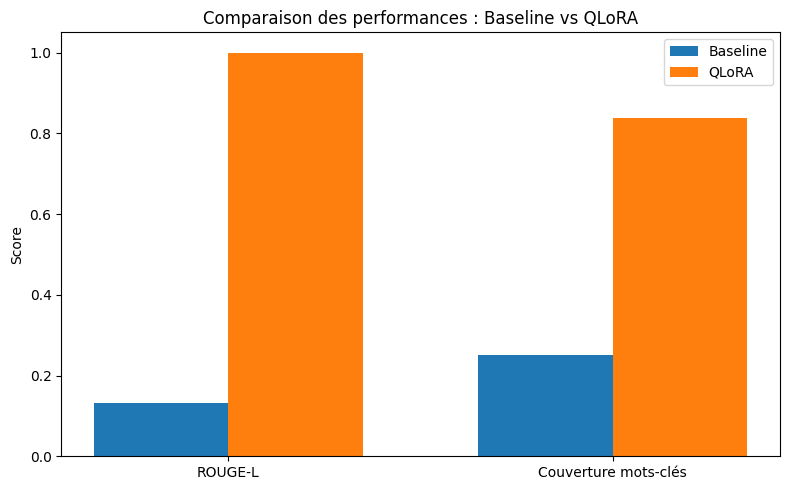

In [37]:
# ============================================================
# VISUALISATION DES MÉTRIQUES
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


labels = [
    "ROUGE-L",
    "Couverture mots-clés",
]

baseline_values = [
    baseline_rouge,
    baseline_keywords,
]

qlora_values = [
    qlora_rouge,
    qlora_keywords,
]


x = np.arange(
    len(labels)
)

width = 0.35


fig, ax = plt.subplots(
    figsize=(8, 5)
)


# Baseline
ax.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Baseline",
)


# QLoRA
ax.bar(
    x + width / 2,
    qlora_values,
    width,
    label="QLoRA",
)


ax.set_ylabel(
    "Score"
)

ax.set_title(
    "Comparaison des performances : Baseline vs QLoRA"
)

ax.set_xticks(x)

ax.set_xticklabels(
    labels
)

ax.set_ylim(
    0,
    1.05
)

ax.legend()


plt.tight_layout()

plt.show()

## 26. Interface applicative

L'interface Gradio n'est plus définie dans le notebook. Elle appartient à `app/app.py`.

L'adaptateur final est sauvegardé dans `artifacts/lora_adapter/`.

In [38]:
# ============================================================
# 26. VÉRIFICATION DE L'INTERFACE ET DU MODÈLE SAUVEGARDÉ
# ============================================================

from pathlib import Path

APP_FILE = PROJECT_ROOT / "app" / "app.py"
ADAPTER_DIR = PROJECT_ROOT / "artifacts" / "lora_adapter"

print("app/app.py :", APP_FILE.exists())
print("Adaptateur QLoRA :", ADAPTER_DIR.exists())

if APP_FILE.exists():
    print(" Interface Gradio trouvée :", APP_FILE)
else:
    print(" app/app.py introuvable")

if ADAPTER_DIR.exists():
    print(" Adaptateur sauvegardé :", ADAPTER_DIR)
else:
    print(" Adaptateur QLoRA introuvable")

app/app.py : True
Adaptateur QLoRA : True
 Interface Gradio trouvée : /content/nlp_tutor/app/app.py
 Adaptateur sauvegardé : /content/nlp_tutor/artifacts/lora_adapter


In [39]:
try:
    demo.close()
except:
    pass

print(" Ancienne interface arrêtée")

 Ancienne interface arrêtée


In [ ]:
%cd /content/nlp_tutor
%run app/app.py

/content
Initialisation de NLP Tutor
CUDA disponible : True
GPU : Tesla T4

Chargement du tokenizer...
Tokenizer chargé.

Chargement du modèle QLoRA...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Modèle QLoRA chargé.
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://39466a5159293009eb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Fermer l'interface locale actuelle
try:
    demo.close()
except Exception:
    pass

# Relancer la même interface avec un lien public
demo.launch(
    share=True,
    show_error=True,
)

Closing server running on port: 7860
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://655e59e74af8fff659.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 27. Conclusion

Ce projet avait pour objectif de construire un assistant pédagogique francophone
spécialisé dans les notions fondamentales du NLP et des Transformers.

Nous avons d'abord étudié plusieurs mécanismes essentiels des modèles de langage :
la tokenisation, les logits, la fonction softmax, l'argmax, la température ainsi
que les stratégies de décodage top-k et top-p.

Une première configuration utilisant Qwen2.5-1.5B-Instruct avec prompting a servi
de baseline. Le même modèle a ensuite été adapté à notre tâche pédagogique avec
QLoRA, en combinant une quantification 4 bits et des adaptateurs LoRA.

Sur l'échantillon de 20 requêtes du jeu de test utilisé pour l'évaluation
automatique, la baseline obtient un ROUGE-L moyen d'environ 0,1331 et une
couverture moyenne des mots-clés de 0,2500.

Après l'adaptation QLoRA, le ROUGE-L moyen atteint 1,0000 et la couverture moyenne
des mots-clés atteint environ 0,8375.

Ces résultats montrent que l'adaptation a fortement rapproché les réponses
générées des réponses de référence du dataset.

Cependant, un ROUGE-L très élevé ne signifie pas que le modèle est parfait.
Cette métrique mesure principalement la proximité textuelle avec une référence
et ne garantit pas à elle seule l'exactitude factuelle ou la capacité de
généralisation.

Pour cette raison, un second ensemble de 20 questions formulées différemment a
été utilisé comme challenge. L'inspection de ces réponses montre que le modèle
QLoRA produit souvent des réponses plus courtes et plus ciblées que la baseline,
mais qu'il peut encore générer certaines réponses hors sujet ou incorrectes.

Le projet met ainsi en évidence à la fois l'intérêt de QLoRA pour spécialiser un
petit modèle avec des ressources GPU limitées et l'importance de compléter les
métriques automatiques par des tests sur de nouvelles formulations.

Enfin, une interface Gradio permet d'utiliser le modèle final sous la forme d'un
assistant pédagogique interactif.

In [ ]:
print("Fichiers de résultats disponibles :")

results_dir = PROJECT_ROOT / "results"

for path in sorted(results_dir.glob("*")):
    if path.is_file():
        print(" -", path.name)

Fichiers de résultats disponibles :
 - baseline_results.csv
 - baseline_vs_qlora.csv
 - challenge_comparison.csv
 - challenge_examples_inspection.csv
 - final_model_tests.csv
 - metrics_summary.csv
 - qlora_results.csv


In [ ]:
from pathlib import Path
import shutil

PROJECT_ROOT = Path("/content/nlp_tutor")

EXPORT_DIR = PROJECT_ROOT / "final_export"

if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)

EXPORT_DIR.mkdir(parents=True)

# Résultats
if (PROJECT_ROOT / "results").exists():
    shutil.copytree(
        PROJECT_ROOT / "results",
        EXPORT_DIR / "results"
    )

# Adaptateur QLoRA
if (PROJECT_ROOT / "artifacts" / "lora_adapter").exists():
    shutil.copytree(
        PROJECT_ROOT / "artifacts" / "lora_adapter",
        EXPORT_DIR / "lora_adapter"
    )

# Application
if (PROJECT_ROOT / "app").exists():
    shutil.copytree(
        PROJECT_ROOT / "app",
        EXPORT_DIR / "app",
        ignore=shutil.ignore_patterns("__pycache__")
    )

# Code source
if (PROJECT_ROOT / "src").exists():
    shutil.copytree(
        PROJECT_ROOT / "src",
        EXPORT_DIR / "src",
        ignore=shutil.ignore_patterns("__pycache__")
    )

# Fichiers du projet
for filename in [
    "README.md",
    "requirements.txt",
    "pyproject.toml",
]:
    src = PROJECT_ROOT / filename

    if src.exists():
        shutil.copy2(src, EXPORT_DIR / filename)

# Notebook
notebook = PROJECT_ROOT / "notebooks" / "agent.ipynb"

if notebook.exists():
    (EXPORT_DIR / "notebooks").mkdir(exist_ok=True)
    shutil.copy2(
        notebook,
        EXPORT_DIR / "notebooks" / "agent.ipynb"
    )

# ZIP final
zip_path = shutil.make_archive(
    str(PROJECT_ROOT / "nlp_tutor_final"),
    "zip",
    EXPORT_DIR
)

print("✅ PROJET FINAL SAUVEGARDÉ")
print(zip_path)

✅ PROJET FINAL SAUVEGARDÉ
/content/nlp_tutor/nlp_tutor_final.zip


In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/content/nlp_tutor")
RESULTS_DIR = PROJECT_ROOT / "results"

baseline = pd.read_csv(
    RESULTS_DIR / "baseline_results.csv"
)

qlora = pd.read_csv(
    RESULTS_DIR / "qlora_results.csv"
)

comparison = pd.read_csv(
    RESULTS_DIR / "baseline_vs_qlora.csv"
)

challenge = pd.read_csv(
    RESULTS_DIR / "challenge_comparison.csv"
)

print("✅ Résultats chargés")

✅ Résultats chargés


In [ ]:
display(comparison)

,id,concept,question,reference,baseline,qlora
0,1,masque causal,C'est quoi masque causal en NLP ?,Un masque causal empêche une position de consu...,Le masque causal est un concept important dans...,Un masque causal empêche une position de consu...
1,2,tokenizer,Comment expliquer tokenizer à un débutant ?,Un tokenizer transforme un texte en tokens pui...,Un tokenizer est comme un petit robot qui divi...,Un tokenizer transforme un texte en tokens pui...
2,3,température,Donne une définition courte puis une explicati...,La température modifie la distribution utilisé...,La température est un concept scientifique qui...,La température modifie la distribution utilisé...
3,4,token,Explique-moi simplement token.,Un token est une unité de texte manipulée par ...,"Un token, aussi appelé ""tokeniser"", est un élé...",Un token est une unité de texte manipulée par ...
4,5,LoRA,Donne-moi une explication pédagogique de LoRA.,LoRA gèle les principaux poids du modèle et aj...,"LoRA, ou Low-Rank Adaptation, est un concept i...",LoRA gèle les principaux poids du modèle et aj...
5,6,fenêtre de contexte,Explique le rôle de fenêtre de contexte.,La fenêtre de contexte est la quantité maximal...,Le rôle de la fenêtre de contexte dans les mod...,La fenêtre de contexte est la quantité maximal...
6,7,embedding,Donne une définition courte puis une explicati...,Un embedding est un vecteur numérique représen...,**Définition :** L'embedding est un concept ce...,Un embedding est un vecteur numérique représen...
7,8,train validation test,Peux-tu définir train validation test ?,"Le train sert à ajuster les paramètres, la val...",Bien sûr ! La division en train-validation-tes...,"Le train sert à ajuster les paramètres, la val..."
8,9,train validation test,Donne une définition courte puis une explicati...,"Le train sert à ajuster les paramètres, la val...",La **validation** est une étape importante dan...,"Le train sert à ajuster les paramètres, la val..."
9,10,attention,Fais un résumé clair de attention.,L'attention permet de pondérer l'importance de...,Attention est un concept fondamental dans le d...,L'attention permet de pondérer l'importance de...


In [ ]:
from pathlib import Path
import shutil

PROJECT_ROOT = Path("/content/nlp_tutor")
EXPORT_DIR = PROJECT_ROOT / "presentation_export"

# Recréer un dossier propre
if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)

EXPORT_DIR.mkdir(parents=True)

# 1. Résultats
results_dir = PROJECT_ROOT / "results"

if results_dir.exists():
    shutil.copytree(
        results_dir,
        EXPORT_DIR / "results"
    )

# 2. Adaptateur QLoRA
adapter_dir = PROJECT_ROOT / "artifacts" / "lora_adapter"

if adapter_dir.exists():
    shutil.copytree(
        adapter_dir,
        EXPORT_DIR / "lora_adapter"
    )

# 3. Application Gradio
app_dir = PROJECT_ROOT / "app"

if app_dir.exists():
    shutil.copytree(
        app_dir,
        EXPORT_DIR / "app",
        ignore=shutil.ignore_patterns("__pycache__")
    )

# 4. Notebook
notebook = PROJECT_ROOT / "notebooks" / "agent.ipynb"

if notebook.exists():
    (EXPORT_DIR / "notebooks").mkdir(exist_ok=True)
    shutil.copy2(
        notebook,
        EXPORT_DIR / "notebooks" / "agent.ipynb"
    )

# 5. Fichiers de configuration
for filename in [
    "README.md",
    "requirements.txt",
    "pyproject.toml",
]:
    src = PROJECT_ROOT / filename

    if src.exists():
        shutil.copy2(
            src,
            EXPORT_DIR / filename
        )

# 6. Créer le ZIP
zip_path = shutil.make_archive(
    "/content/nlp_tutor_presentation",
    "zip",
    EXPORT_DIR
)

print("✅ ZIP créé :")
print(zip_path)

✅ ZIP créé :
/content/nlp_tutor_presentation.zip


In [ ]:
from pathlib import Path

zip_file = Path("/content/nlp_tutor_presentation.zip")

print("Existe :", zip_file.exists())

if zip_file.exists():
    print("Chemin :", zip_file)
    print(f"Taille : {zip_file.stat().st_size / 1024**2:.2f} Mo")

Existe : True
Chemin : /content/nlp_tutor_presentation.zip
Taille : 29.79 Mo


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import shutil

shutil.copy2(
    "/content/nlp_tutor_presentation.zip",
    "/content/drive/MyDrive/nlp_tutor_presentation.zip"
)

print("✅ Copié dans Google Drive")

✅ Copié dans Google Drive
